In [1]:
from toy_model import *
from metrics import *
import wandb
import torch
import numpy as np

/opt/anaconda3/envs/toytrans/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

wandb.login()

wandb: Currently logged in as: ce24b119 (jerrycloud3316-ai-club-iit-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# to find kl loss between model and these processes
T0_proc1 = np.array([
    [0, 1, 0],
    [0, 0, 1], 
    [0, 0, 0.5]
])
T1_proc1 = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0.5, 0, 0]
])

# Different process
T0_proc2 = np.array([
    [0,1,0],
    [0,0,0],
    [0.5,0,0]
])
T1_proc2 = np.array([
    [0,0,0],
    [0,0,1],
    [0.5,0,0]
])
T0_proc3 = np.array([
    [0,1,0,0],
    [0,0,0,0.5],
    [0.5,0,0,0],
    [0,0,0,0.5]])
T1_proc3 = np.array([
    [0,0,0,0],
    [0,0,0.5,0],
    [0.5,0,0,0],
    [0.5,0,0,0]])   
process1 = MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1], seed=43)
process2 = MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc2, T1_proc2], seed=43)
process3 = MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)

In [4]:
dataset1=MarkovData(n_gen=5000, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1])
dataset2=MarkovData(n_gen=5000, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc2, T1_proc2])
merged_dataset = MergeMarkovDatasets(dataset1=dataset1, dataset2=dataset2,mixing_style='random')
for i in range (10):
    print(merged_dataset[i])

{'tokens': tensor([1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 1, 0])}
{'tokens': tensor([0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 0, 1, 0, 0, 1, 1, 0])}
{'tokens': tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        0, 0, 1, 0, 0, 1, 0, 0])}
{'tokens': tensor([0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        0, 1, 0, 0, 0, 1, 0, 0])}
{'tokens': tensor([0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1])}
{'tokens': tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
        0, 0, 1, 0, 0, 0, 0, 0])}
{'tokens': tensor([1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 0])}
{'tokens': tensor([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 1, 0])}


In [11]:
x=torch.stack(merged_dataset.data)
onegramfreq, onegramcounts, onegramtotal=get_ngram_stats(x, n=1)
print(onegramfreq, onegramcounts, onegramtotal)
twogramfreq, twogramcounts, twogramtotal=get_ngram_stats(x, n=2)
print(twogramfreq, twogramcounts, twogramtotal)
threegramfreq, threegramcounts, threegramtotal=get_ngram_stats(x, n=3)
print(threegramfreq, threegramcounts, threegramtotal)


{'0': 0.625671875, '1': 0.374328125} {'0': 200215, '1': 119785} 320000
{'00': 0.3337322580645161, '01': 0.2922451612903226, '10': 0.29033870967741937, '11': 0.08368387096774194} {'00': 103457, '01': 90596, '10': 90005, '11': 25942} 310000
{'000': 0.12573, '001': 0.20832333333333333, '010': 0.20825666666666667, '011': 0.08375, '100': 0.20673333333333332, '101': 0.08354666666666667, '110': 0.08366, '111': 0.0} {'000': 37719, '001': 62497, '010': 62477, '011': 25125, '100': 62020, '101': 25064, '110': 25098, '111': 0} 300000


In [4]:
dataset1=MarkovData(n_gen=50, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1], seed=43)
dataset2=MarkovData(n_gen=50, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc2, T1_proc2], seed=43)
test_dataset = MergeMarkovDatasets(dataset1=dataset1, dataset2=dataset2,mixing_style='random')

In [5]:
dataset_sriram=MarkovData(n_gen=10000, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3])

In [7]:
print(dataset_sriram[0])

{'tokens': tensor([1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        0, 1, 1, 0, 1, 1, 0, 0])}


In [6]:
test_data=MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)

In [7]:

metrics_config = MetricsConfig(
    track_markov_kl=True,
    markov_processes=[process1,process2,process3], 
    pos_start=5,
    
    track_ngrams=True,
    ngram_data=test_data,
    ngram_orders=[1, 2, 3],
    track_previous_token=True,
    track_in_context=False, 
    icl_data=test_data,
    icl_k1=5,
    icl_k2=32,
    track_composition=True,
    track_prefix_matching=False)

In [ ]:
model=load_model("proc1/seq_len32/X7/model300.pt","proc1/seq_len32/X7/model_cfg.pt")
print(model.cfg)

In [ ]:
model=load_model("proc1/seq_len32/X4/model300.pt","proc1/seq_len32/X4/model_cfg.pt")
print(model.cfg)

In [8]:

model = train_model(
    dataset=dataset_sriram,
    n_layers=2,
    d_model=4,
    n_heads=2, 
    attn_only=False,
    act_fn='silu',
    normalization_type='LN',

    n_epochs=300,
    batch_size=64,
    lr=0.05,

    wandb=True,
    wandb_project_name="ICL",
    save_dir="proc1/seq_len32/proc3_d_model4",
    save_every=20,
    print_every=10,


    metrics_config=metrics_config,
    metrics_log_interval=20
    )
wandb.finish()

Moving model to device:  cpu


  0%|          | 0/300 [00:00<?, ?it/s]

Metrics logged at step 50
Metrics logged at step 100


  0%|          | 1/300 [00:01<08:37,  1.73s/it]

Epoch 1 Validation Loss 0.6388952732086182
Metrics logged at step 150
Metrics logged at step 200


...

100%|█████████▉| 299/300 [09:13<00:02,  2.07s/it]

Epoch 299 Validation Loss 0.587731122970581
Metrics logged at step 37400
Metrics logged at step 37450


100%|██████████| 300/300 [09:15<00:00,  1.85s/it]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Metrics logged at step 37500
Epoch 300 Samples 8000 Step 124 Training Loss 0.5879509449005127
Epoch 300 Validation Loss 0.5884837508201599


1gram_kl_model_to_true,▁▃▃▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▄▄▄▅▅▆▃▄▄▅▅▄▅▇▅▆█
1gram_kl_true_to_model,▁▁▁▁▁▁▁▁▂▁▂▂▁▂▃▁▂▃▃▂▂▃▂▂▂▃▃▄▅▄▄▄▄▄▄▅▇█▇▇
2gram_kl_model_to_true,▁▁▁▁▁▁▁▁▁▂▂▃▅▃▃▃▃▄▃▄▃▄▅▂▃▃▄▄▄▅▅▆▆▅▇▅▆▇██
2gram_kl_true_to_model,▁▁▁▁▁▁▁▂▂▂▂▂▂▄▂▃▃▃▃▃▃▃▃▃▄▄▂▃▃▃▃▄▄▄▄▄▅▄▇█
3gram_kl_model_to_true,▂▂▂▂▃▂▃▂▃▂▃▃▃▃▄▃▂▃▁▂▅▄▂▇▅▅▆▃▅▇▆▅▃▆▅▅█▅▅▅
3gram_kl_true_to_model,▁▂▂▂▂▂▂▃▃▃▃▄▃▄▃▄▂▄▄▄▄▅▃▃▃▄▄▄▃▄▄▄▅▆▆▄▆▇▆█
avg_k_composition_l0_l1,█████▇▆▅▅▅▅▅▄▄▄▄▄▄▃▄▅▅▅▆▆▇██▆▆▃▂▂▂▂▂▁▁▁▃
avg_prev_token_matching,▂███▇▇▆▆▆▆▆▄▄▃▄▃▃▂▁▁▃▄▄▅▃▄▄███▇▇▇▇▆▇▇▇▇▆
avg_q_composition_l0_l1,▁▂▂▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▄▄▄▄▄▄▅▇▇▆▆▆▅▆▅▅▅▅█
avg_v_composition_l0_l1,▃▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▂▂▂▃▂▃▅▄▄▄▄▄▃▃▄▄▄▅▆▆██
+28,...


O_2: training on original process for baseline

In [5]:
original_dataset=MarkovData(n_gen=10000, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3])
for i in range(10):
    print(original_dataset[i])

{'tokens': tensor([1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        0, 1, 1, 0, 1, 1, 0, 0])}
{'tokens': tensor([1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 0, 1, 0, 0, 0])}
{'tokens': tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
        0, 1, 0, 0, 1, 0, 0, 0])}
{'tokens': tensor([1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 1, 0, 0, 1])}
{'tokens': tensor([0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 1, 0, 0, 1, 1])}
{'tokens': tensor([1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 1])}
{'tokens': tensor([0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 0, 1, 0, 0, 0])}
{'tokens': tensor([1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 0])}


In [6]:
test_dataset=MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)

In [ ]:
x=torch.stack(original_dataset.data)
onegramfreq, onegramcounts, onegramtotal=get_ngram_stats(x, n=1)
print(onegramfreq, onegramcounts, onegramtotal)
twogramfreq, twogramcounts, twogramtotal=get_ngram_stats(x, n=2)
print(twogramfreq, twogramcounts, twogramtotal)
threegramfreq, threegramcounts, threegramtotal=get_ngram_stats(x, n=3)
print(threegramfreq, threegramcounts, threegramtotal)


In [7]:

metrics_config = MetricsConfig(
    track_markov_kl=True,
    markov_processes=[process1,process2,process3], 
    pos_start=5,
    
    track_ngrams=True,
    ngram_data=test_dataset,
    ngram_orders=[1, 2, 3],
    track_previous_token=True,
    track_in_context=False, 
    icl_data=test_dataset,
    icl_k1=5,
    icl_k2=32,
    track_composition=True,
    track_prefix_matching=False)

In [8]:
model = train_model(
    dataset=original_dataset,
    n_layers=2,
    d_model=16,
    n_heads=2, 
    attn_only=False,
    act_fn='silu',
    normalization_type= 'LN',

    n_epochs=300,
    batch_size=64,
    lr=0.05,

    wandb=True,
    wandb_project_name="ICL",
    save_dir="proc1/seq_len32/o7*_ln",
    save_every=20,
    print_every=10,


    metrics_config=metrics_config,
    metrics_log_interval=20
    )
wandb.finish()

Moving model to device:  cpu


  0%|          | 0/300 [00:00<?, ?it/s]

Metrics logged at step 50
Metrics logged at step 100


  0%|          | 1/300 [00:02<10:10,  2.04s/it]

Epoch 1 Validation Loss 0.6227516531944275
Metrics logged at step 150
Metrics logged at step 200


...

100%|█████████▉| 299/300 [10:55<00:02,  2.14s/it]

Epoch 299 Validation Loss 0.5119631886482239
Metrics logged at step 37400
Metrics logged at step 37450


100%|██████████| 300/300 [10:57<00:00,  2.19s/it]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Metrics logged at step 37500
Epoch 300 Samples 8000 Step 124 Training Loss 0.5137851238250732
Epoch 300 Validation Loss 0.5110957622528076


1gram_kl_model_to_true,▁▁▁▁▂▅▄▅▅▅▆▆▇▇█▇▇▇▇▇▇███████▇█▇█▇██▇████
1gram_kl_true_to_model,▁▁▁▁▁▂▂▂▂▂▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
2gram_kl_model_to_true,▁▁▂▂▃▄▄▅▅▅▄▆▆▆▅▇█▇▇▇▇█▇█▇█▇█▇███████████
2gram_kl_true_to_model,▁▁▁▂▃▃▄▃▃▄▅▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████
3gram_kl_model_to_true,▁▃▁▁▂▃▅▂▆▆▅▇▆▅▆▆▆▇▆▆▇▆▅█▇▆▇▆▆▆█▆▇▇▆▅█▆▇▆
3gram_kl_true_to_model,▁▁▁▂▂▃▃▃▄▄▄▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
avg_k_composition_l0_l1,▁▂▃▄▆▇▇▇▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
avg_prev_token_matching,▁▁▁▂▂▄▄▄▅▅▆▆▆▆▇▇▇▇▇▇▇███▇███████████████
avg_q_composition_l0_l1,██▇▇▆▁▁▁▁▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▂▃▂
avg_v_composition_l0_l1,▁▁▂▂▃▅▅▅▅▅▃▃▄▃▃▃▃▄▄▄▅▅▅▅▅▆▆▇▇▇██████████
+28,...


In [5]:
from numpy import dtype


def icl_kl(model, test_data, start_pos, end_pos, print_val:Optional=False):
    model.eval()
    x=torch.stack(test_data.data)  # (n_gen, gen_len)
    n_gen, gen_len=x.shape
    x_cond=x[:,:start_pos-1]  # (n_gen, start_pos)
    x_pred=x[:,start_pos:end_pos]  # (n_gen, end_pos-start_pos)
    kl_values=[]
    token_probs=[]

    #print(test_data.states[0][0])
    for seq in range(n_gen):
        seq_probs=[]
        for t in range(gen_len):
            eta=test_data.states[seq][t]
            probs=test_data.model.token_probabilities(eta)
            seq_probs.append(probs)
        token_probs.append(seq_probs)
    token_probs=torch.tensor(token_probs,dtype=torch.float32)  # (n_gen, gen_len, d_vocab)
    with torch.no_grad():
        for p in range (start_pos, end_pos,1):
            logits=model(x[:,:p])  # (n_gen, p, d_vocab)
            #print(logits.shape)
            next_token_logit=logits[:, -1, :]
            next_token_prob=torch.softmax(next_token_logit, dim=-1)
            markov_next_token_prob = token_probs[:, p, :]
            #markov_next_token_prob=token_probs[:,p,:]
            #markov_next_token_prob=torch.tensor(markov_next_token_prob, dtype=torch.float32)
            next_token_prob_clamped=torch.clamp(next_token_prob, min=1e-8)
            markov_next_token_prob_clamped=torch.clamp(markov_next_token_prob, min=1e-8)
            kl_div=torch.sum(next_token_prob_clamped*torch.log(next_token_prob_clamped/markov_next_token_prob_clamped), dim=-1)
            kl_mean=kl_div.mean().item()
            kl_values.append(kl_mean)
            if print_val==True:
                print(f"Position {start_pos+p}: KL divergence {kl_div.mean().item()}")
    return kl_values

In [6]:

test_data_proc2=MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc2, T1_proc2], seed=43)
test_data_proc1=MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1], seed=43)
test_data_proc3=MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)

In [10]:
import matplotlib.pyplot as plt

In [11]:
import re

In [8]:
def plot_icl(model_path,cfg_path,test_data,proc_name,start,end,print_val:Optional=False):
    model=load_model(model_path, cfg_path)
    kl_vals=icl_kl(model, test_data, start, end,print_val)
    plt.figure(figsize=(40,6))
    model_name=re.search(r"seq_len32/(.+)", model_path).group(1)
    plt.plot(range(start,end), kl_vals, label=f"{model_name} on ")
    plt.xlabel("Position")
    plt.ylabel("KL divergence")
    plt.title(f"{model_name} on {proc_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

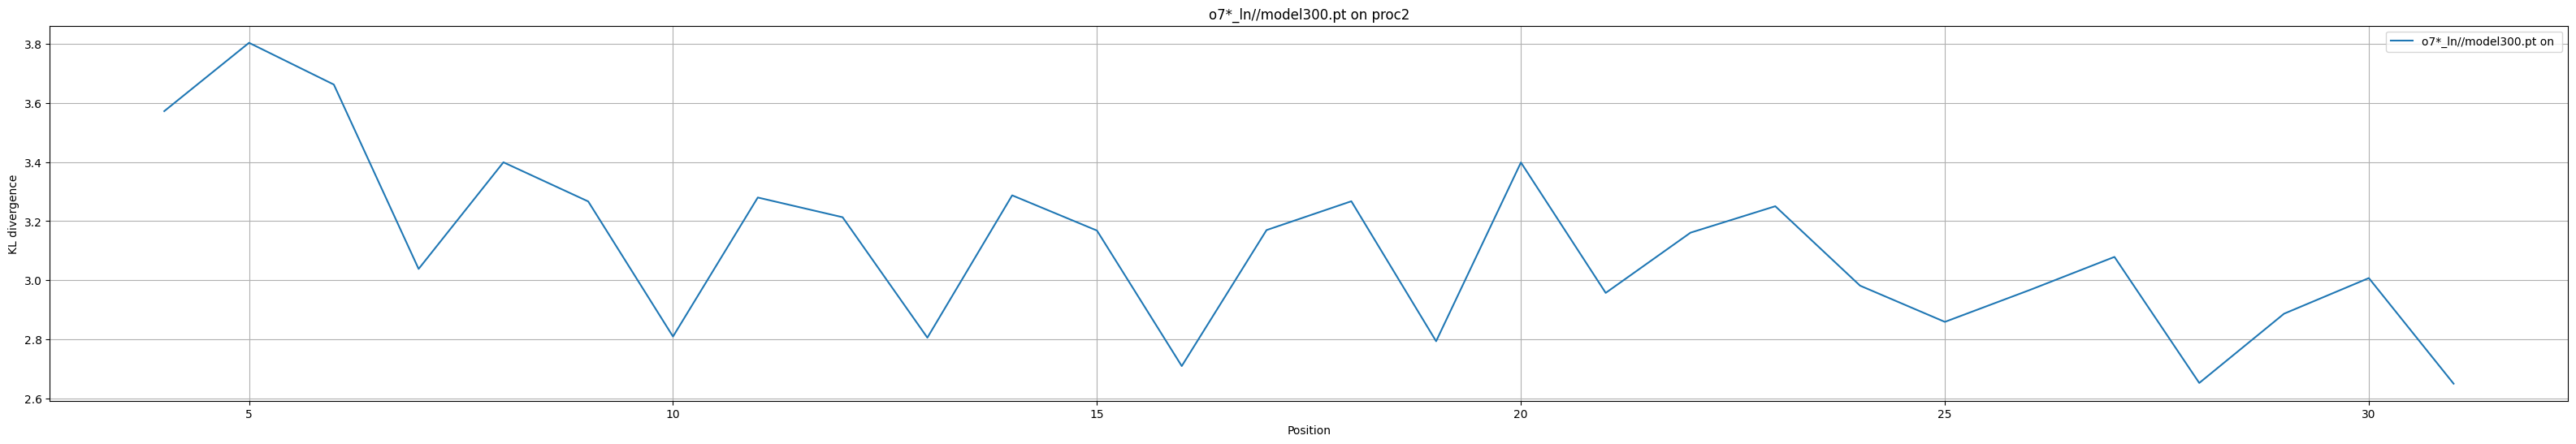

In [49]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc2,"proc2",4,32)

Position 2: KL divergence 0.09308931976556778
Position 3: KL divergence 1.943121314048767
Position 4: KL divergence 3.842531442642212
Position 5: KL divergence 3.5718894004821777
Position 6: KL divergence 3.803004264831543
Position 7: KL divergence 3.66184663772583
Position 8: KL divergence 3.0385825634002686
Position 9: KL divergence 3.399005174636841
Position 10: KL divergence 3.2667434215545654
Position 11: KL divergence 2.8099851608276367
Position 12: KL divergence 3.279994010925293
Position 13: KL divergence 3.21333646774292
Position 14: KL divergence 2.806164503097534
Position 15: KL divergence 3.2873151302337646
Position 16: KL divergence 3.168236494064331
Position 17: KL divergence 2.710179090499878
Position 18: KL divergence 3.169854164123535
Position 19: KL divergence 3.267305850982666
Position 20: KL divergence 2.7940568923950195
Position 21: KL divergence 3.3984036445617676
Position 22: KL divergence 2.9575023651123047
Position 23: KL divergence 3.1610705852508545
Position 

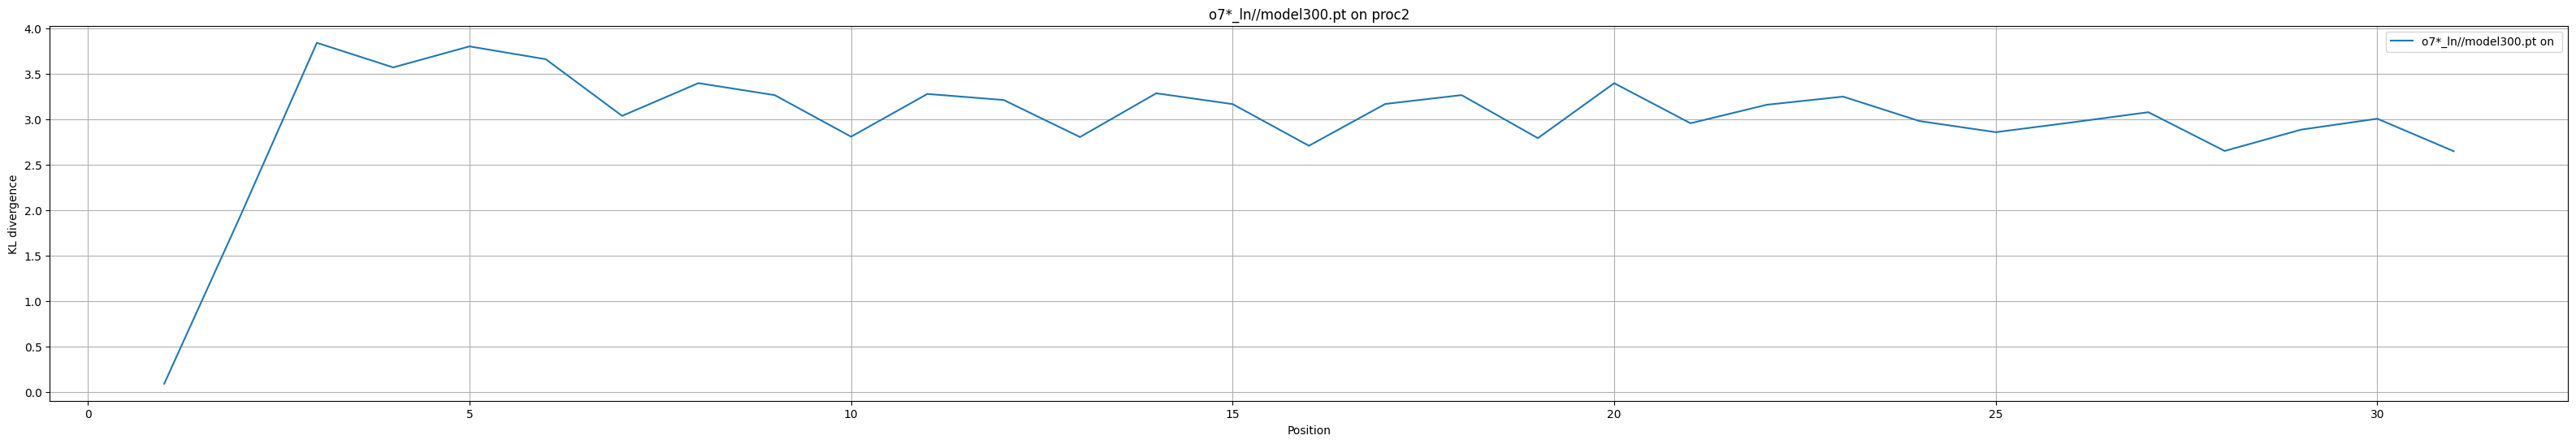

In [63]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc2,"proc2",1,32, print_val=True)

Position 2: KL divergence 0.0009641025681048632
Position 3: KL divergence 0.001235138508491218
Position 4: KL divergence 0.0006862187292426825
Position 5: KL divergence 0.0026861834339797497
Position 6: KL divergence 0.0012999241007491946
Position 7: KL divergence 0.002486427780240774
Position 8: KL divergence 0.0017587528564035892
Position 9: KL divergence 0.003318884177133441
Position 10: KL divergence 0.0014244731282815337


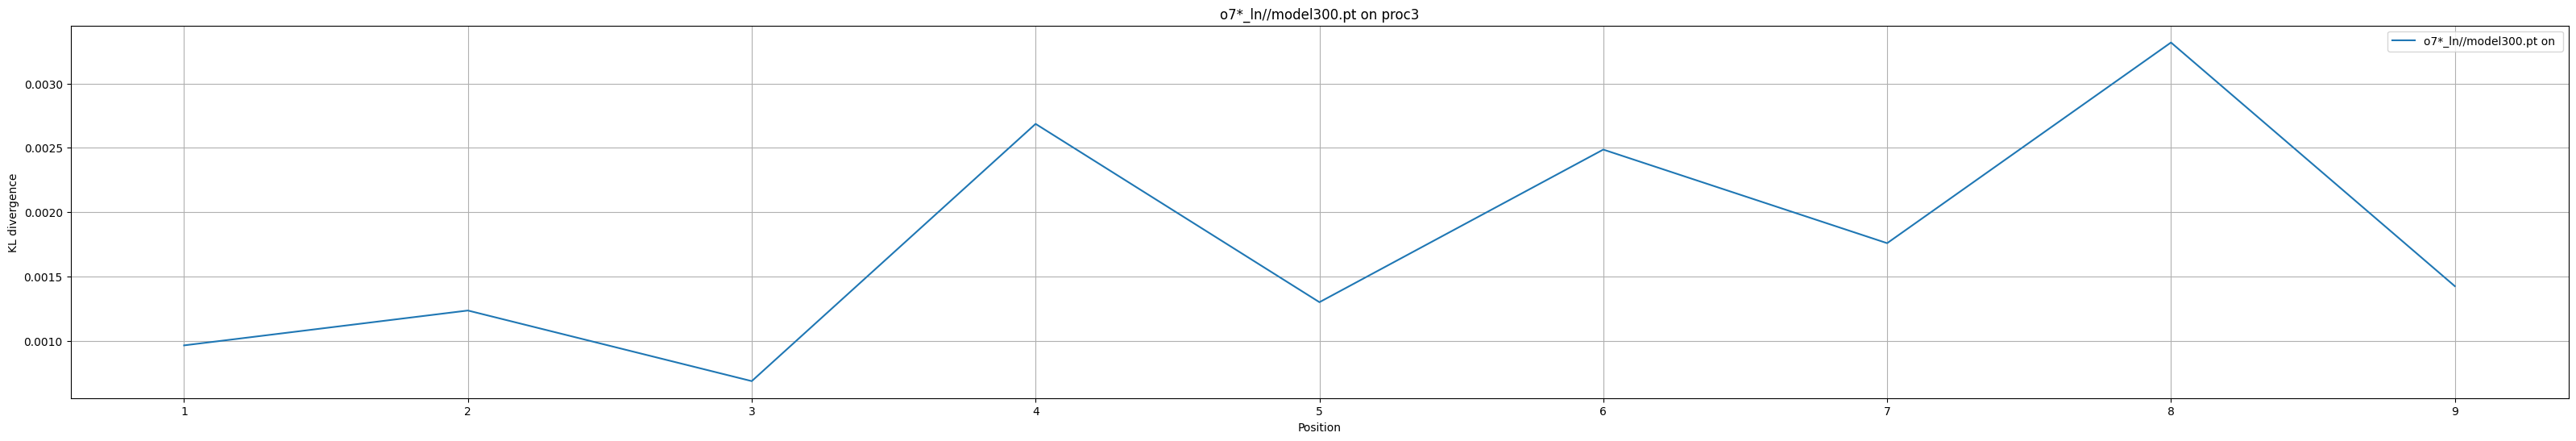

In [62]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc3,"proc3",1,10,print_val=True)

Position 2: KL divergence 0.0009641025681048632
Position 3: KL divergence 0.001235138508491218
Position 4: KL divergence 0.0006862187292426825
Position 5: KL divergence 0.0026861834339797497
Position 6: KL divergence 0.0012999241007491946
Position 7: KL divergence 0.002486427780240774
Position 8: KL divergence 0.0017587528564035892
Position 9: KL divergence 0.003318884177133441
Position 10: KL divergence 0.0014244731282815337
Position 11: KL divergence 0.0015610211994498968
Position 12: KL divergence 0.0015676175244152546
Position 13: KL divergence 0.0027743694372475147
Position 14: KL divergence 0.015845423564314842
Position 15: KL divergence 0.004318044986575842
Position 16: KL divergence 0.01832771673798561
Position 17: KL divergence 0.049065299332141876
Position 18: KL divergence 0.001453033066354692
Position 19: KL divergence 0.010028972290456295
Position 20: KL divergence 0.06028414145112038
Position 21: KL divergence 0.0022731097415089607
Position 22: KL divergence 0.08591043204

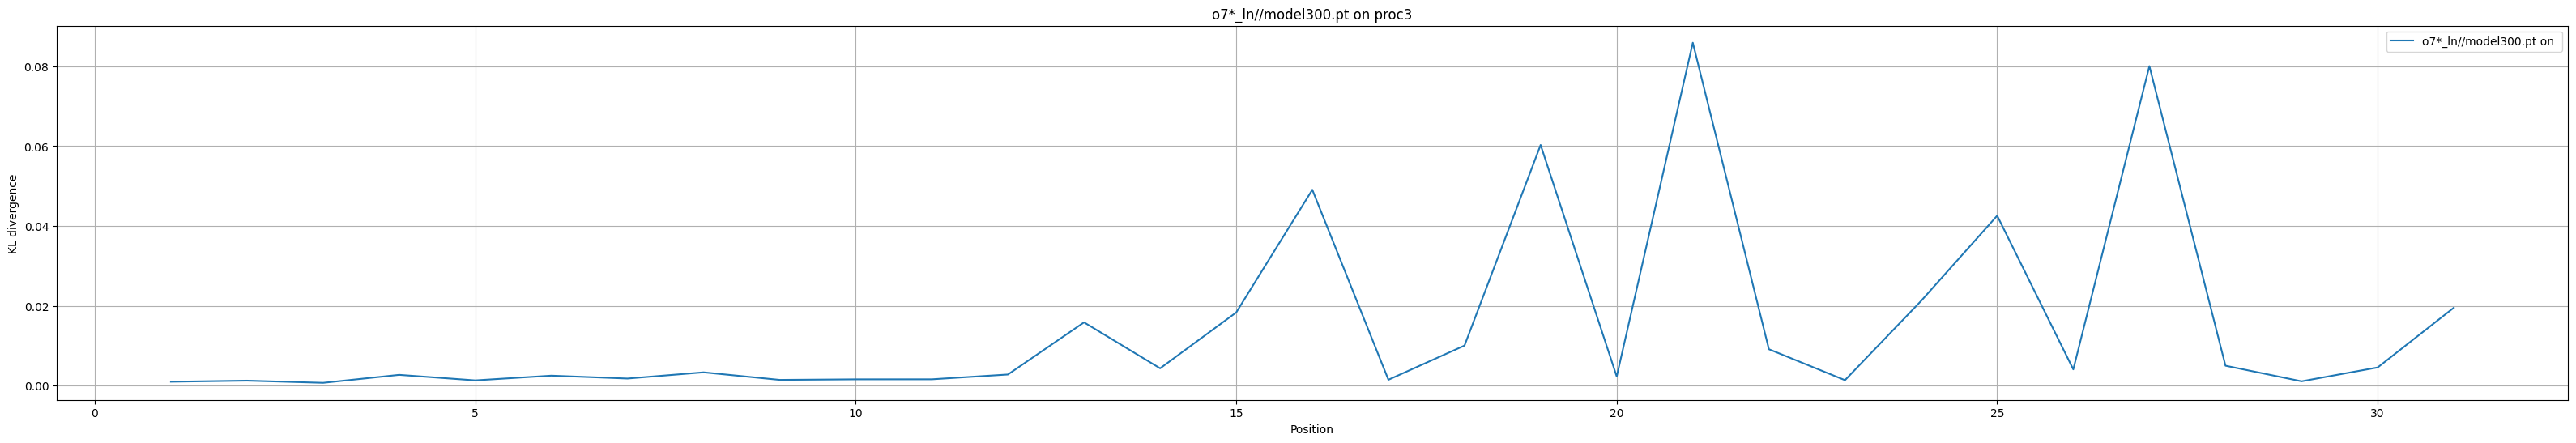

In [13]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc3,"proc3",1,32,print_val=True)

Position 2: KL divergence 2.2584838006878272e-05
Position 3: KL divergence 0.004521056544035673
Position 4: KL divergence 0.0009560376638546586
Position 5: KL divergence 0.015617839060723782
Position 6: KL divergence 0.006110497750341892
Position 7: KL divergence 0.011605105362832546
Position 8: KL divergence 0.0476577989757061
Position 9: KL divergence 0.01785818114876747
Position 10: KL divergence 0.04024398699402809
Position 11: KL divergence 0.03953995555639267
Position 12: KL divergence 0.05936267971992493
Position 13: KL divergence 0.05578753352165222
Position 14: KL divergence 0.05425868555903435
Position 15: KL divergence 0.0634143203496933
Position 16: KL divergence 0.09484782814979553
Position 17: KL divergence 0.10580755025148392
Position 18: KL divergence 0.00782869290560484
Position 19: KL divergence 0.014577197842299938
Position 20: KL divergence 0.05614488199353218
Position 21: KL divergence 0.017295243218541145
Position 22: KL divergence 0.01981949619948864
Position 23:

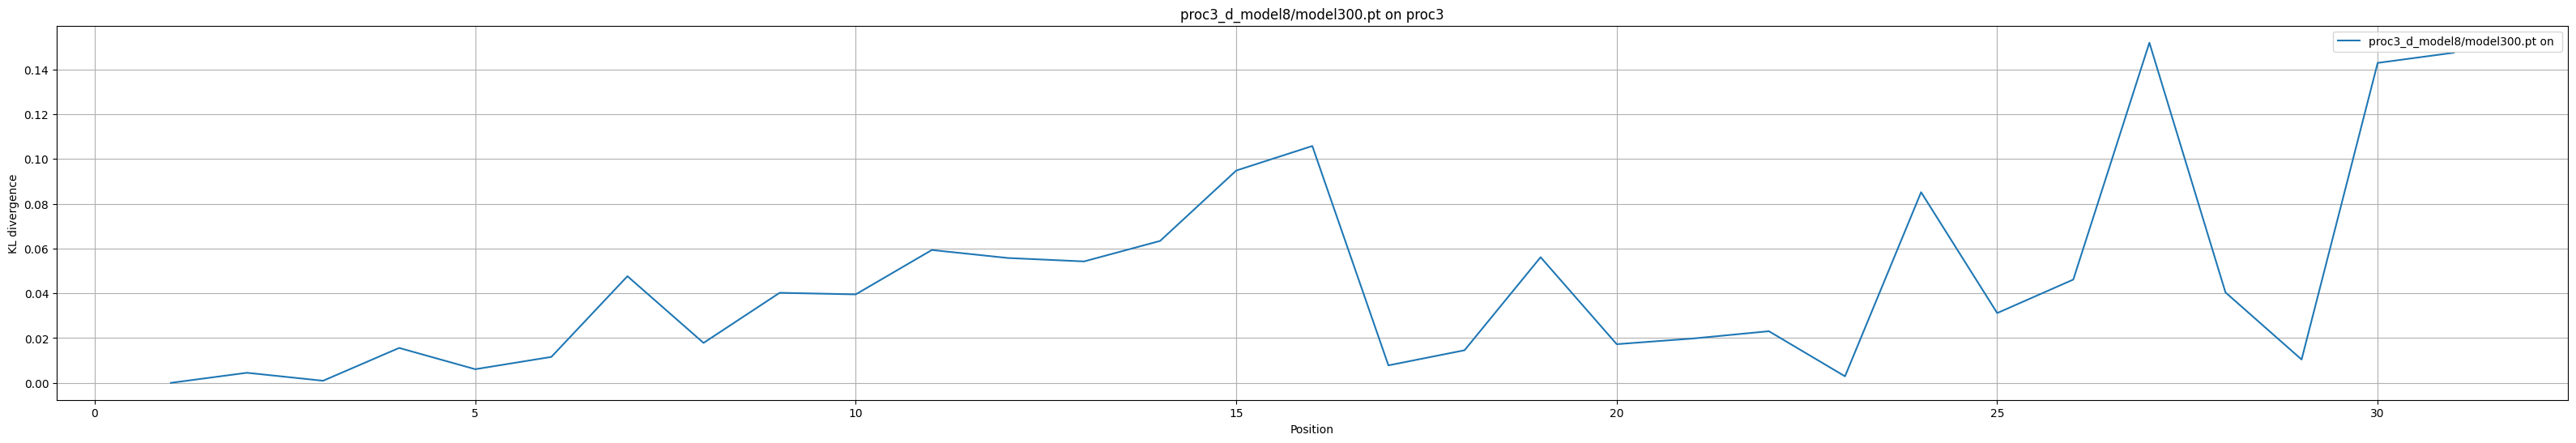

In [12]:
plot_icl("proc1/seq_len32/proc3_d_model8/model300.pt","proc1/seq_len32/proc3_d_model8/model_cfg.pt",test_data_proc3,"proc3",1,32,print_val=True)

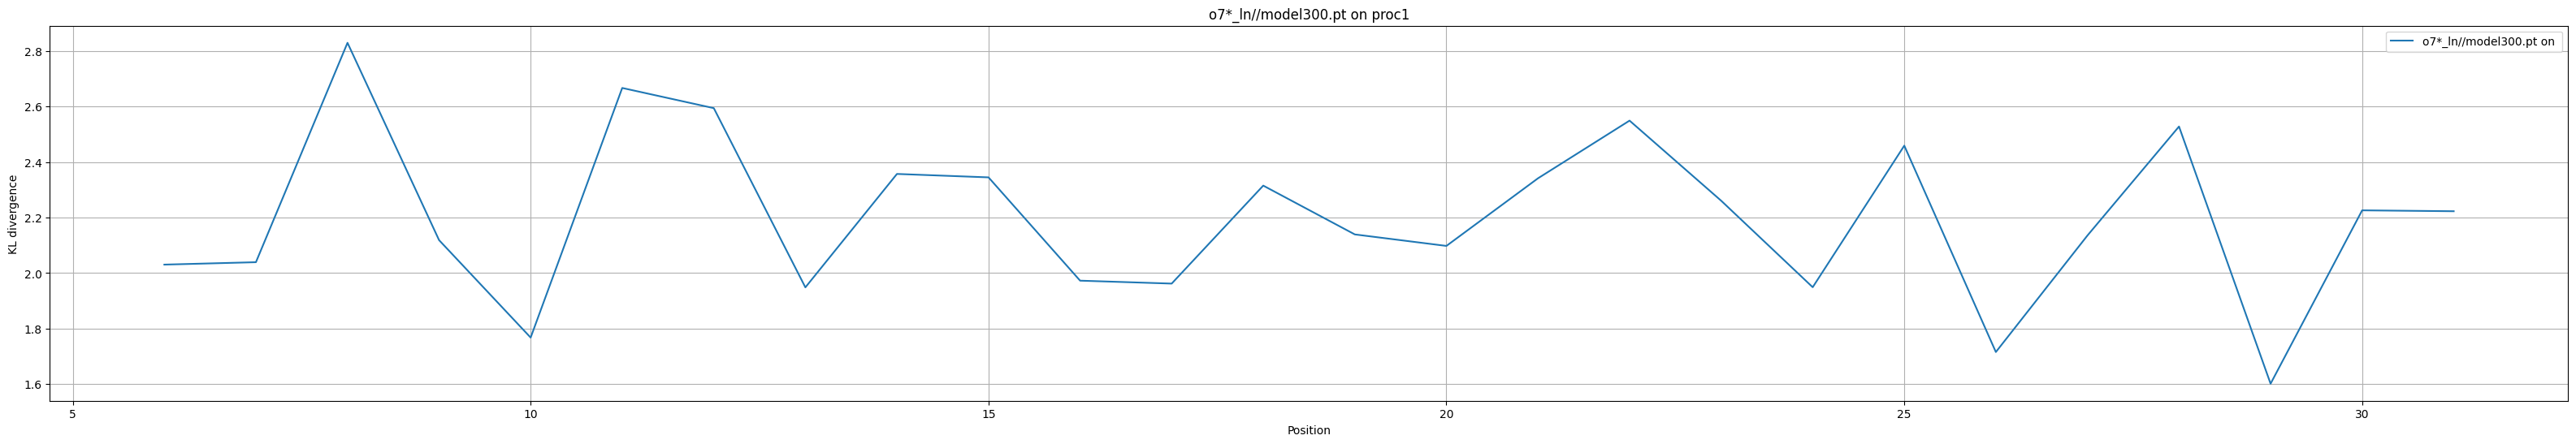

In [53]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc1,"proc1",6,32)

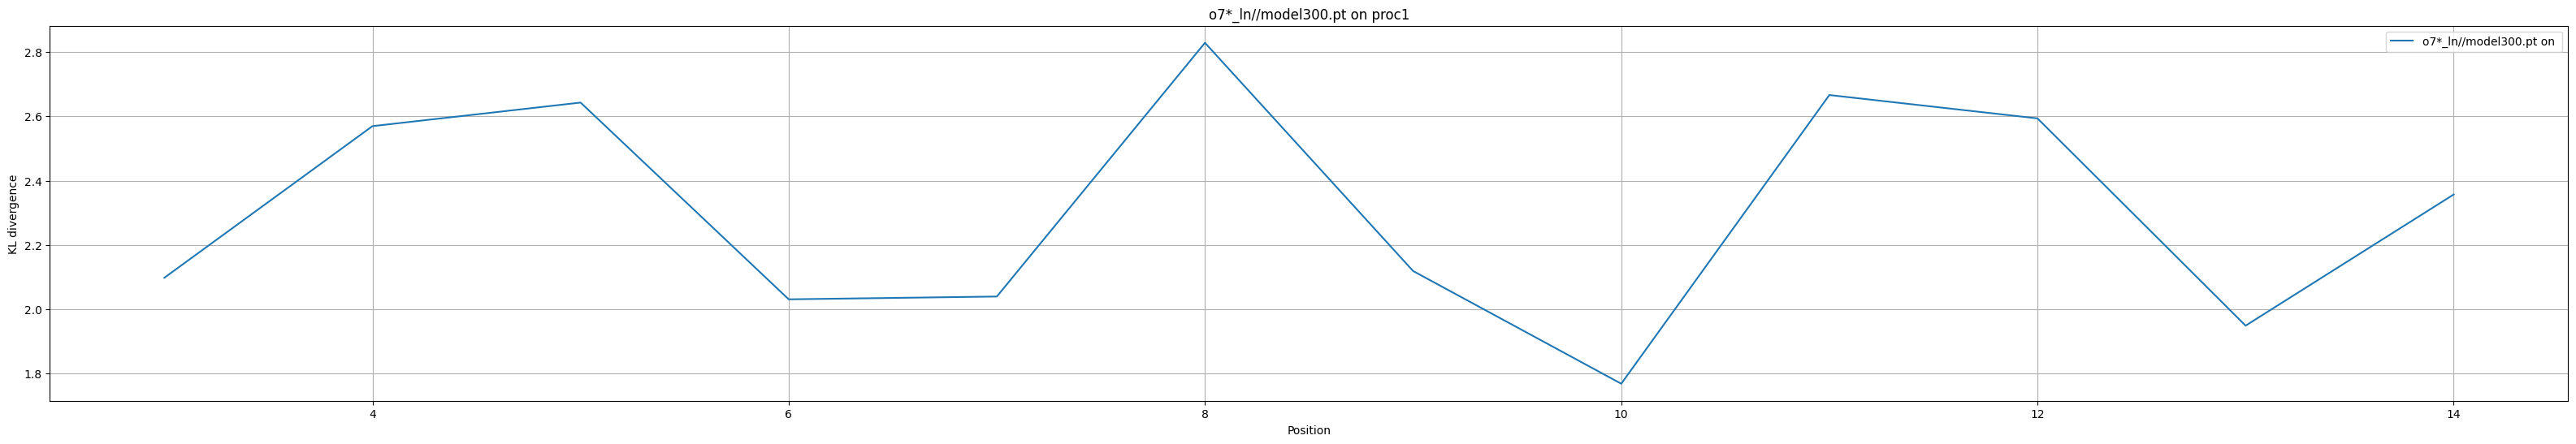

In [56]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc1,"proc1",3,15)

Position 40: KL divergence 2.097705602645874
Position 41: KL divergence 2.3411593437194824
Position 42: KL divergence 2.5488693714141846
Position 43: KL divergence 2.2605929374694824
Position 44: KL divergence 1.9490141868591309
Position 45: KL divergence 2.4587202072143555
Position 46: KL divergence 1.7156039476394653
Position 47: KL divergence 2.1351864337921143
Position 48: KL divergence 2.5276718139648438
Position 49: KL divergence 1.6015411615371704
Position 50: KL divergence 2.225848913192749
Position 51: KL divergence 2.2226204872131348


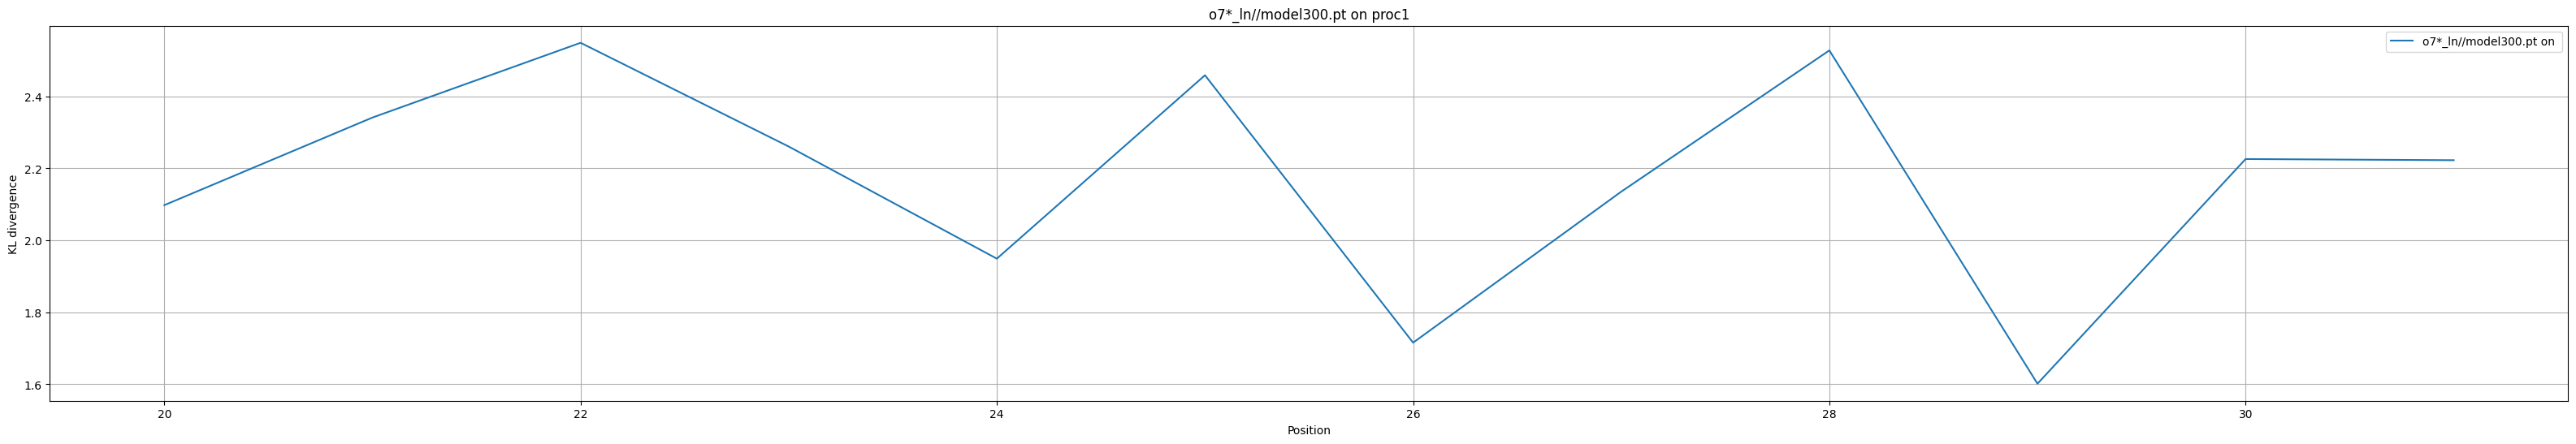

In [64]:
plot_icl("proc1/seq_len32/o7*_ln//model300.pt","proc1/seq_len32/o7*_ln//model_cfg.pt",test_data_proc1,"proc1",20,32,print_val=True)

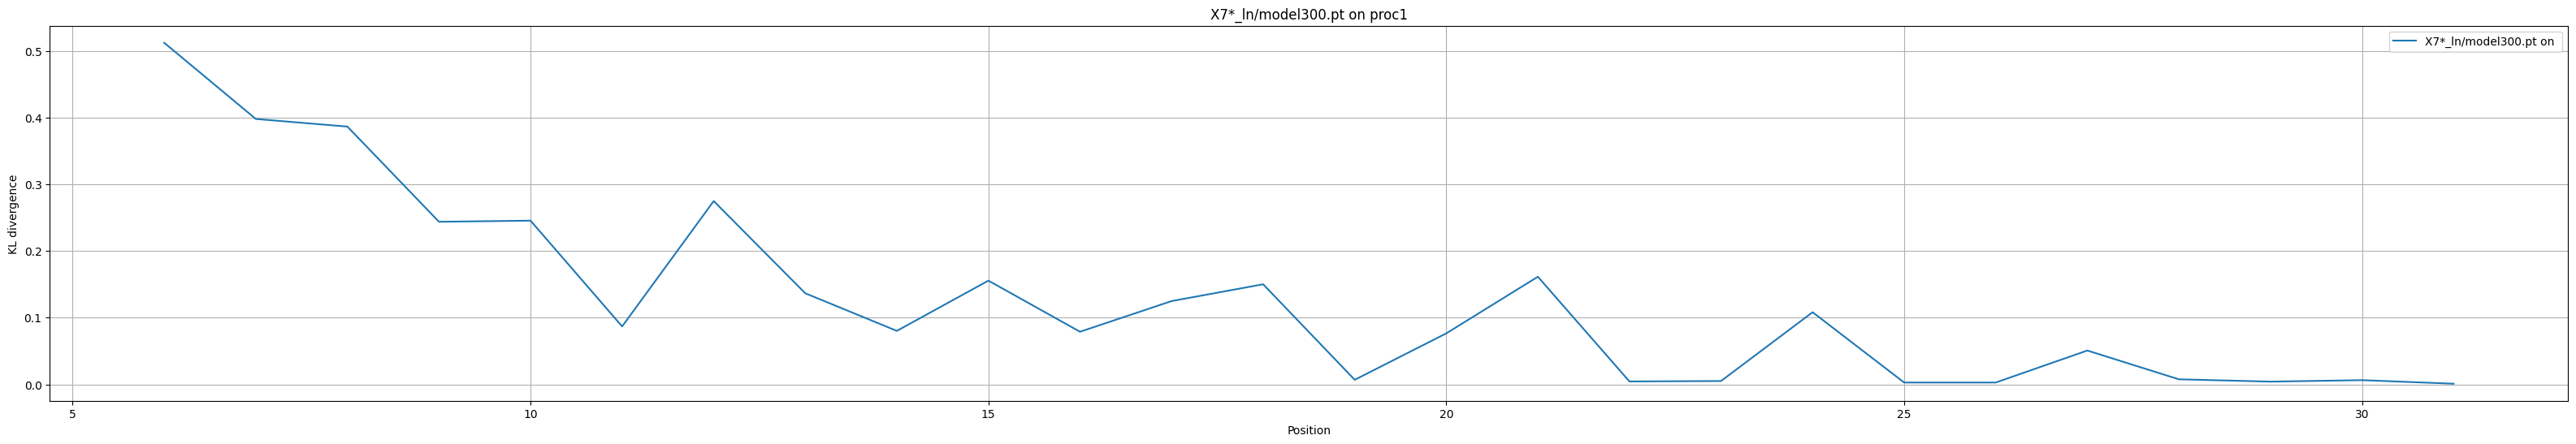

In [57]:
plot_icl("proc1/seq_len32/X7*_ln/model300.pt","proc1/seq_len32/X7*_ln/model_cfg.pt",test_data_proc1,"proc1",6,32)

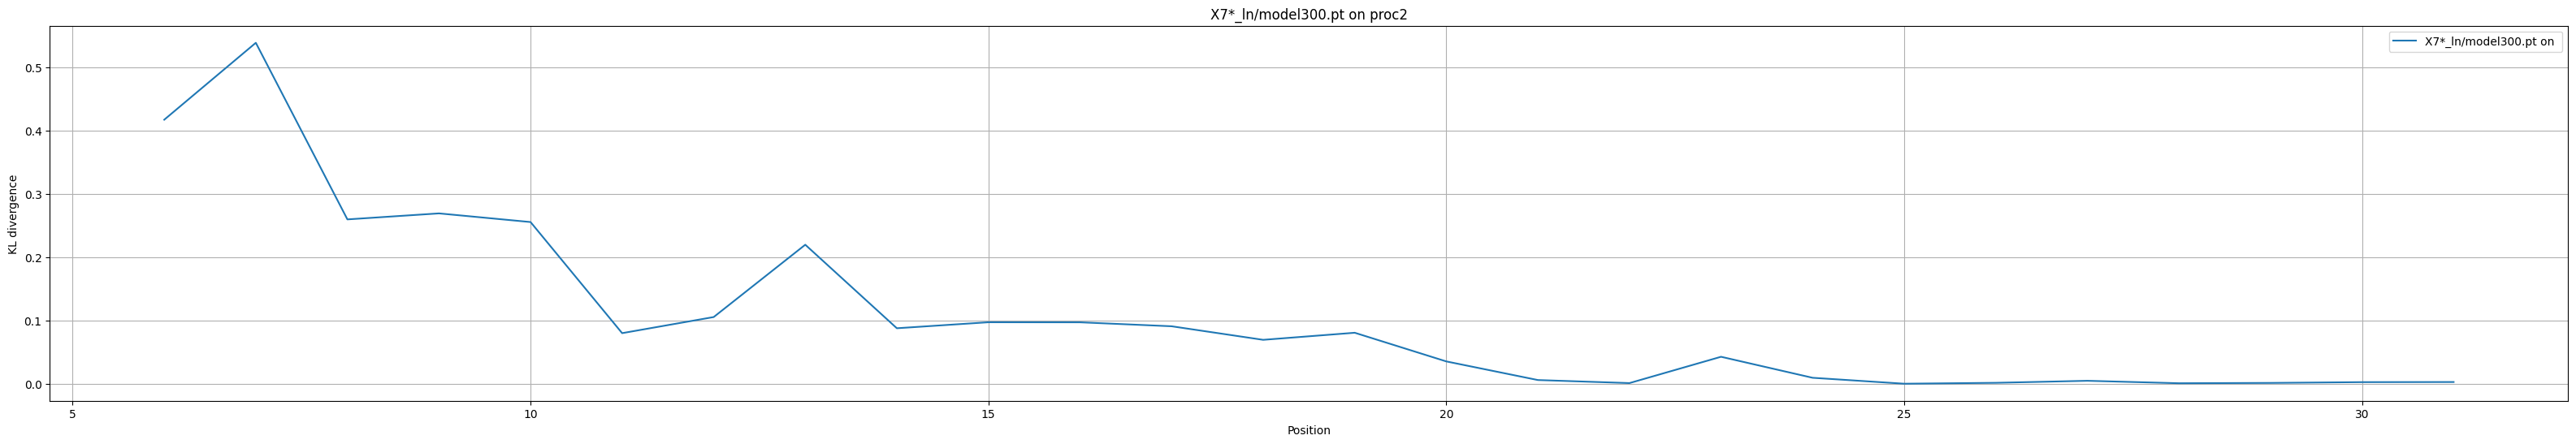

In [58]:
plot_icl("proc1/seq_len32/X7*_ln/model300.pt","proc1/seq_len32/X7*_ln/model_cfg.pt",test_data_proc2,"proc2",6,32)

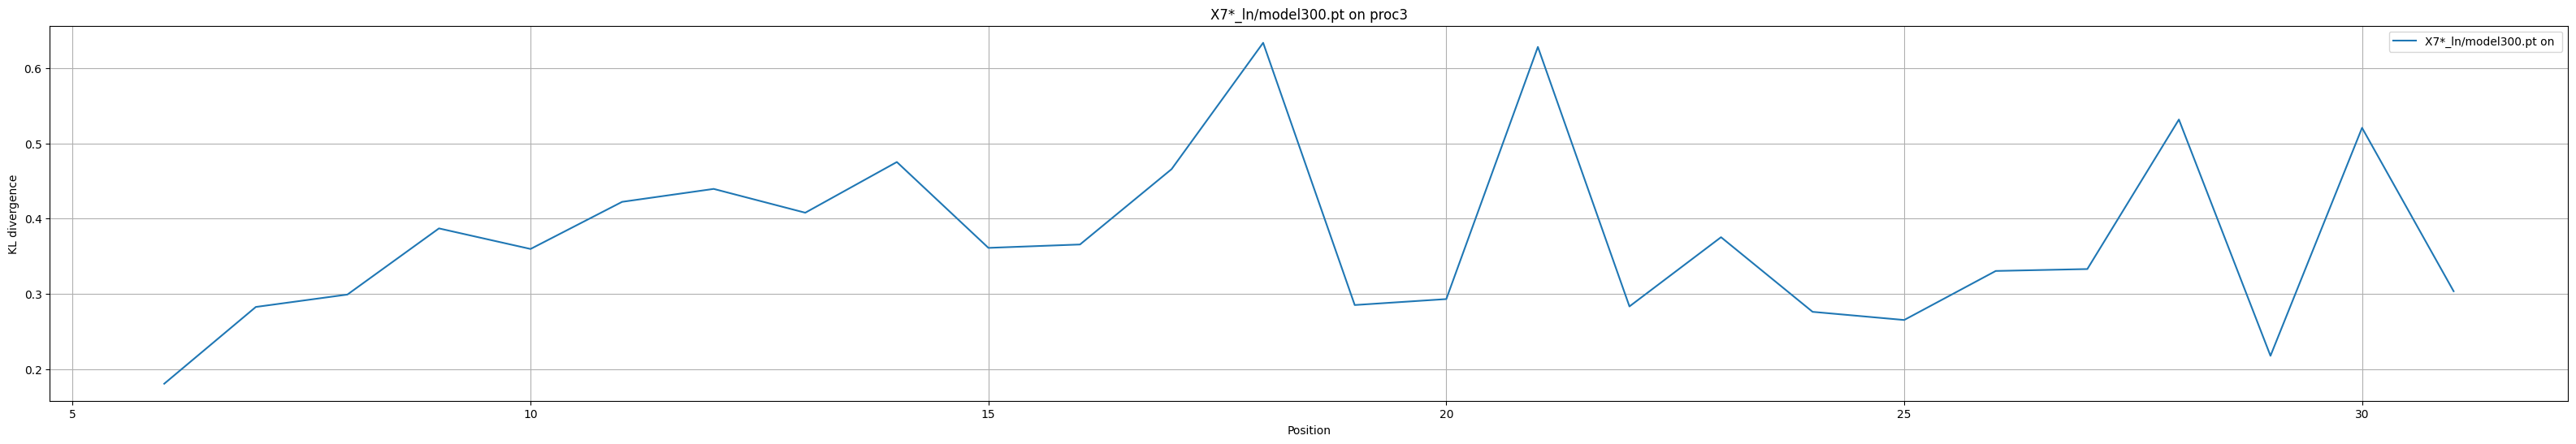

In [59]:
plot_icl("proc1/seq_len32/X7*_ln/model300.pt","proc1/seq_len32/X7*_ln/model_cfg.pt",test_data_proc3,"proc3",6,32)

In [73]:
plot_icl("proc1/seq_len32/Z7/model300.pt","proc1/seq_len32/Z7/model_cfg.pt",test_data_proc1,"proc1",6,32)

FileNotFoundError: [Errno 2] No such file or directory: 'proc1/seq_len32/Z7/model_cfg.pt'

[0.33333333 0.33333333 0.33333333]
Position 12: KL divergence 0.5210426449775696
Position 13: KL divergence 0.3764937222003937
Position 14: KL divergence 0.38391968607902527
Position 15: KL divergence 0.2620649039745331
Position 16: KL divergence 0.24614377319812775
Position 17: KL divergence 0.09496433287858963
Position 18: KL divergence 0.21783122420310974
Position 19: KL divergence 0.13041305541992188
Position 20: KL divergence 0.07563736289739609
Position 21: KL divergence 0.07390956580638885
Position 22: KL divergence 0.07718820124864578
Position 23: KL divergence 0.13591405749320984
Position 24: KL divergence 0.17213496565818787
Position 25: KL divergence 0.004635851830244064
Position 26: KL divergence 0.0823126807808876
Position 27: KL divergence 0.18564952909946442
Position 28: KL divergence 0.006404055282473564
Position 29: KL divergence 0.013118491508066654
Position 30: KL divergence 0.11168637871742249
Position 31: KL divergence 0.010946784168481827
Position 32: KL divergenc

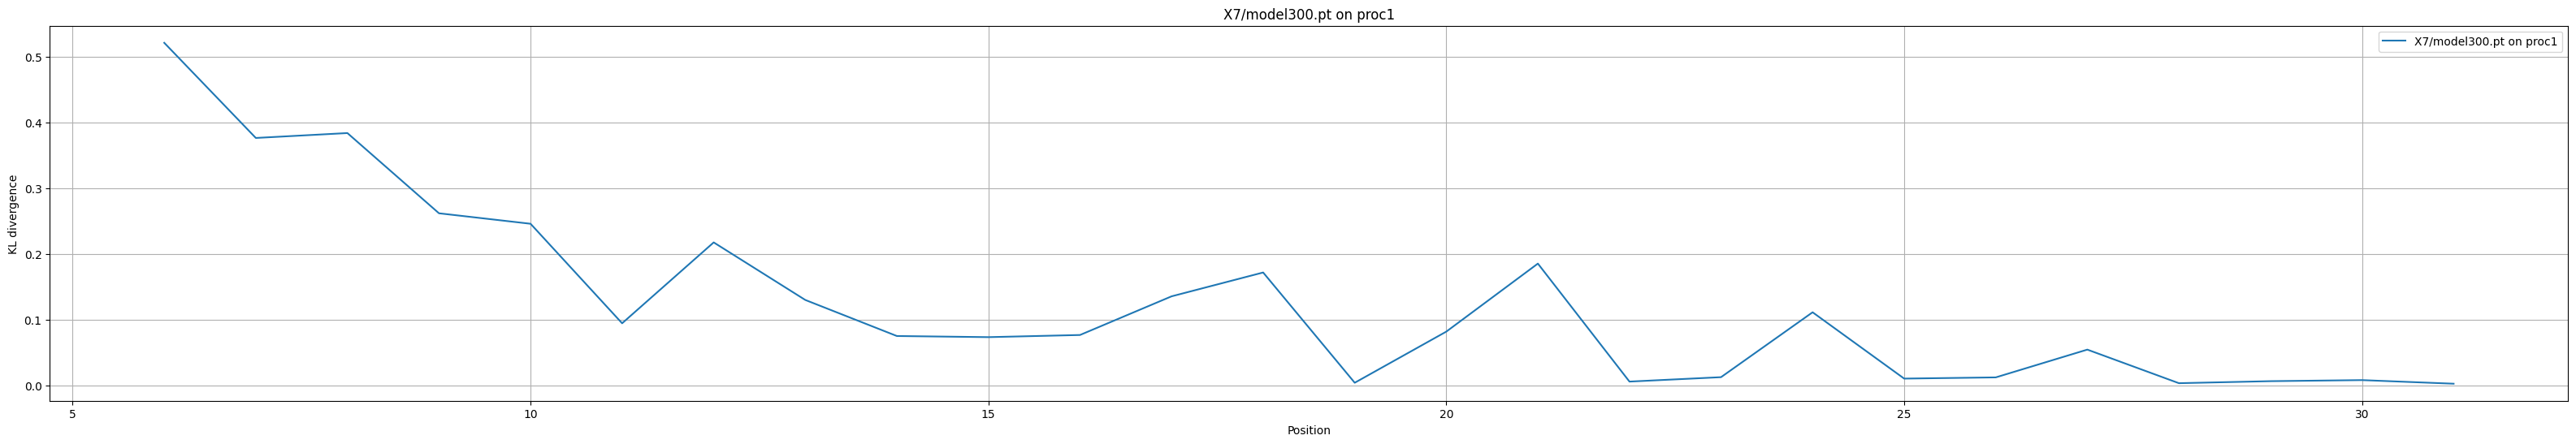

In [25]:
model_path="proc1/seq_len32/X7/model300.pt"
model_cfg_path="proc1/seq_len32/X7/model_cfg.pt"
test_data=test_data_proc1
model_name=re.search(r"seq_len32/(.+)", model_path).group(1)

model=load_model(model_path, model_cfg_path)
kl_vals=icl_kl(model, test_data, start_pos=6, end_pos=32)
plt.figure(figsize=(40,6))
plt.plot(range(6,32), kl_vals, label=f"{model_name} on proc1")
plt.xlabel("Position")
plt.ylabel("KL divergence")
plt.title(f"{model_name} on proc1")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plot

In [ ]:
import matplotlib.pyplot as plt

kl_results = {}  # store {checkpoint: [kl_values across positions]}
model=load_model("proc1/seq_len32/X7*/model300.pt","proc1/seq_len32/X7*/model_cfg.pt")
test_date=MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)
for i in range(280, 300, 20):
    model = load_model(f"proc1/seq_len32/Z1/model{i}.pt",
                       f"proc1/seq_len32/Z1/model_cfg.pt")
    kl_vals = icl_kl(model=model, test_data=test_date, start_pos=2, end_pos=31)
    kl_results[i] = kl_vals  # list of KL losses per position

# Plotting
plt.figure(figsize=(40, 6))

positions = list(range(2, 31))  # token positions on x-axis

for ckpt, vals in kl_results.items():
    plt.plot(positions, vals, label=f"Model {ckpt}")

plt.xlabel("Token position")
plt.ylabel("KL divergence")
plt.title("KL divergence across positions for different model checkpoints")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


kl_results = {}  # store {checkpoint: [kl_values across positions]}
model_name="X7*"
test_data=MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1], seed=43)
for i in range(280, 310, 20):
    model = load_model(f"proc1/seq_len32/{model_name}/model{i}.pt",
                       f"proc1/seq_len32/{model_name}/model_cfg.pt")
    kl_vals = icl_kl(model=model, test_data=test_data, start_pos=2, end_pos=31)
    kl_results[i] = kl_vals  # list of KL losses per position

# Plotting
plt.figure(figsize=(40, 6))

positions = list(range(2, 31))  # token positions on x-axis

for ckpt, vals in kl_results.items():
    plt.plot(positions, vals, label=f"Model {ckpt}")

plt.xlabel("Token position")
plt.ylabel("KL divergence")
plt.title("KL divergence across positions for different model checkpoints")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


kl_results = {}  # store {checkpoint: [kl_values across positions]}
model_name="X7*"
test_data=MarkovData(n_gen=100, gen_len=32, n_states=4, d_vocab=2, T_list=[T0_proc3, T1_proc3], seed=43)
for i in range(300, 310, 20):
    model = load_model(f"proc1/seq_len32/{model_name}/model{i}.pt",
                       f"proc1/seq_len32/{model_name}/model_cfg.pt")
    kl_vals = icl_kl(model=model, test_data=test_data, start_pos=2, end_pos=31)
    kl_results[i] = kl_vals  # list of KL losses per position

# Plotting
plt.figure(figsize=(40, 6))

positions = list(range(2, 31))  # token positions on x-axis

for ckpt, vals in kl_results.items():
    plt.plot(positions, vals, label=f"Model {ckpt}")

plt.xlabel("Token position")
plt.ylabel("KL divergence")
plt.title("KL divergence across positions for different model checkpoints")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

kl_results = {}  # store {checkpoint: [kl_values across positions]}
model_name="X7*_"
test_data=MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc2, T1_proc2], seed=43)
for i in range(300, 310, 20):
    model = load_model(f"proc1/seq_len32/{model_name}/model{i}.pt",
                       f"proc1/seq_len32/{model_name}/model_cfg.pt")
    kl_vals = icl_kl(model=model, test_data=test_data, start_pos=2, end_pos=31)
    kl_results[i] = kl_vals  # list of KL losses per position

# Plotting
plt.figure(figsize=(40, 6))

positions = list(range(2, 31))  # token positions on x-axis

for ckpt, vals in kl_results.items():
    plt.plot(positions, vals, label=f"Model {ckpt}")

plt.xlabel("Token position")
plt.ylabel("KL divergence")
plt.title("KL divergence across positions for different model checkpoints")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

kl_results = {}  # store {checkpoint: [kl_values across positions]}
model=load_model("proc1/seq_len32/X7*/model300.pt","proc1/seq_len32/X7*/model_cfg.pt")
test_date=MarkovData(n_gen=100, gen_len=32, n_states=3, d_vocab=2, T_list=[T0_proc1, T1_proc1], seed=43)
for i in range(300, 310, 20):
    model = load_model(f"proc1/seq_len32/Z1/model{i}.pt",
                       f"proc1/seq_len32/Z1/model_cfg.pt")
    kl_vals = icl_kl(model=model, test_data=test_date, start_pos=2, end_pos=31)
    kl_results[i] = kl_vals  # list of KL losses per position

# Plotting
plt.figure(figsize=(40, 6))

positions = list(range(2, 31))  # token positions on x-axis

for ckpt, vals in kl_results.items():
    plt.plot(positions, vals, label=f"Model {ckpt}")

plt.xlabel("Token position")
plt.ylabel("KL divergence")
plt.title("KL divergence across positions for different model checkpoints")
plt.legend()
plt.grid(True)
plt.show()